In [1]:
#Name:Joel John Jobinse
#Register No: 212223240062
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import confusion_matrix
import seaborn as sns

from PIL import Image

print("PyTorch Version:", torch.__version__)

print("CUDA available:", torch.cuda.is_available())

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

PyTorch Version: 2.7.1+cpu
CUDA available: False
Device: cpu


In [2]:
import zipfile
import os

zip_path = "Cat-Dog_Pandas-20260520T050420Z-3-001.zip"

extract_path = "./data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("Files extracted to:", extract_path)

Dataset extracted successfully!
Files extracted to: ./data


In [3]:
seed = 42

random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
train_transform = transforms.Compose([
    
    transforms.Resize((224,224)),
    
    transforms.RandomHorizontalFlip(),
    
    transforms.RandomRotation(15),
    
    transforms.RandomResizedCrop(
        224,
        scale=(0.8,1.0)
    ),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    
    transforms.Resize((224,224)),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [5]:
dataset_path = "./data"

full_dataset = datasets.ImageFolder(
    dataset_path,
    transform=train_transform
)

print(full_dataset.classes)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size,val_size]
)

val_dataset.dataset.transform = test_transform

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

['Cat-Dog_Pandas']
Training images: 2400
Validation images: 600


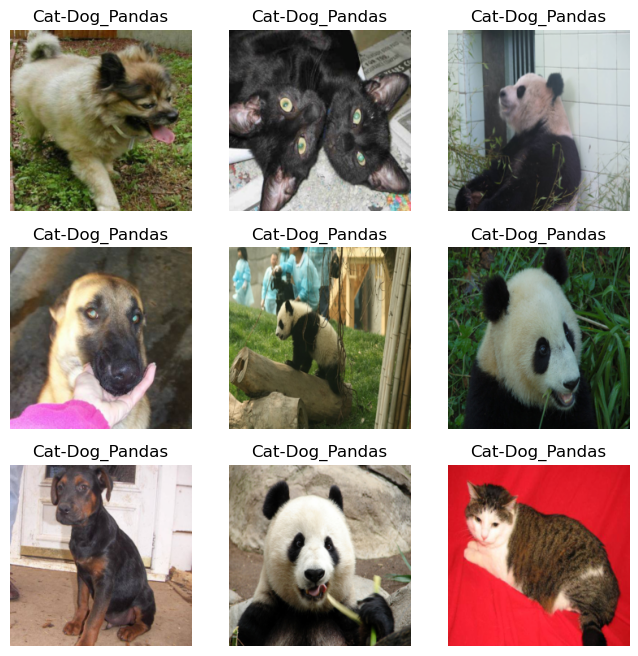

In [6]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(
    3,
    3,
    figsize=(8,8)
)

for i, ax in enumerate(axes.flat):
    
    img = images[i].permute(1,2,0).numpy()
    
    img = img * np.array([0.229,0.224,0.225])
    img += np.array([0.485,0.456,0.406])
    
    img = np.clip(img,0,1)

    ax.imshow(img)
    
    ax.set_title(
        full_dataset.classes[
            labels[i]
        ]
    )
    
    ax.axis("off")

plt.show()

In [7]:
model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features

model.fc = nn.Sequential(
    
    nn.Linear(
        num_features,
        256
    ),
    
    nn.ReLU(),
    
    nn.Dropout(0.5),
    
    nn.Linear(
        256,
        3
    )
)

model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.01
)

In [10]:
epochs = 5

best_acc = 0

for epoch in range(epochs):

    model.train()

    train_loss = 0

    correct = 0

    total = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            preds == labels
        ).sum().item()

    train_acc = correct / total

    model.eval()

    val_correct = 0

    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                preds == labels
            ).sum().item()

    val_acc = val_correct / val_total

    print(
        f"Epoch {epoch+1}"
    )

    print(
        f"Train Accuracy: {train_acc:.4f}"
    )

    print(
        f"Validation Accuracy: {val_acc:.4f}"
    )

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

        print(
            "Saved best model"
        )

Epoch 1
Train Accuracy: 0.9896
Validation Accuracy: 1.0000
Saved best model
Epoch 2
Train Accuracy: 1.0000
Validation Accuracy: 1.0000
Epoch 3
Train Accuracy: 1.0000
Validation Accuracy: 1.0000
Epoch 4
Train Accuracy: 1.0000
Validation Accuracy: 1.0000
Epoch 5
Train Accuracy: 1.0000
Validation Accuracy: 1.0000


In [11]:
model.load_state_dict(
    torch.load(
        "best_model.pth"
    )
)

model.eval()

predictions = []

actual = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(
            outputs,
            1
        )

        predictions.extend(
            preds.cpu().numpy()
        )

        actual.extend(
            labels.numpy()
        )

accuracy = np.mean(
    np.array(
        predictions
    ) == np.array(
        actual
    )
)

print(
    "Test Accuracy:",
    accuracy
)

Test Accuracy: 1.0


C:\Users\admin\.conda\envs\deeplearning\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


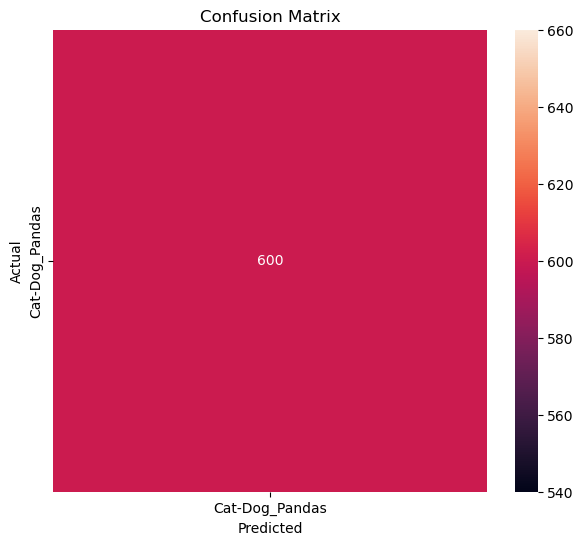

In [13]:
cm = confusion_matrix(
    actual,
    predictions
)

plt.figure(
    figsize=(7,6)
)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    xticklabels=full_dataset.classes,

    yticklabels=full_dataset.classes
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Confusion Matrix"
)

plt.show()